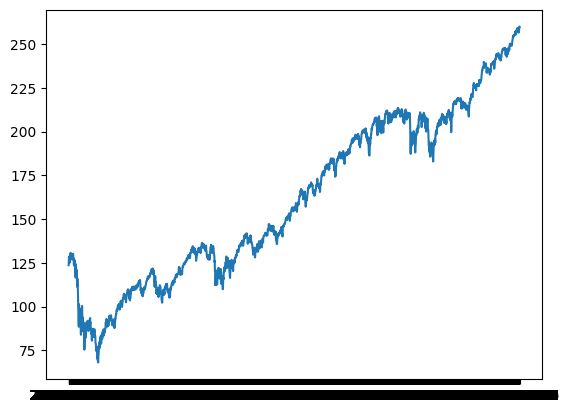

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
PATH = "/Users/ravontekriegler/Documents/GitHub/ML-NextDayReturn/data/raw/spy.csv"
df = pd.read_csv(PATH)
df = df = df.iloc[3902:6252].reset_index(drop=True)
dates = df["Date"]
close = df["Close"]
plt.plot(dates,close)
plt.show()

In [29]:
df

,Date,Open,High,Low,Close,Adj Close,Volume,target
30,1993-03-15,45.062500,45.312500,45.062500,45.312500,26.781643,310800,45.165625
31,1993-03-16,45.312500,45.437500,45.312500,45.312500,26.781643,30800,45.268750
32,1993-03-17,45.250000,45.250000,44.968750,45.031250,26.615404,21800,45.306250
33,1993-03-18,45.218750,45.500000,45.218750,45.312500,26.781643,59300,45.296875
34,1993-03-19,45.281250,45.281250,45.031250,45.031250,26.741098,66900,45.340625
...,...,...,...,...,...,...,...,...
7024,2020-12-18,370.970001,371.149994,367.019989,369.179993,369.179993,136542300,368.565002
7025,2020-12-21,364.970001,378.459991,362.029999,367.859985,367.859985,96386700,368.498001
7026,2020-12-22,368.209991,368.329987,366.029999,367.239990,367.239990,47949000,368.375000
7027,2020-12-23,368.279999,369.619995,367.220001,367.570007,367.570007,46201400,368.081998


Random tree: price prediction
Linear regression: direction


Both seperate predictions but final result should come with conformation or non conformation of price raise or lowering using linear regression as the conformation

targets are the price 2 weeks out


---




In [30]:
df['target'] = df['Close'].shift(1).rolling(10).mean()
df = df.dropna()

def findavg(df):
    avg_10 = df["Close"].shift(1).rolling(10).mean()
    yesterday_close = df["Close"].shift(1)

    pct_from_avg = (yesterday_close - avg_10) / avg_10
    estimated_price = df["Close"] * (1 + pct_from_avg)

    return estimated_price


df["avg_10"] = df["Close"].shift(1).rolling(10).mean()
df["pct_from_avg"] = (df["Close"].shift(1) - df["avg_10"]) / df["avg_10"]
df["estimated_price"] = df["Close"] * (1 + df["pct_from_avg"])


In [33]:
df.corr(numeric_only=True)["target"].sort_values()

pct_from_avg       0.002794
Volume             0.151642
Adj Close          0.992314
estimated_price    0.996642
Low                0.998763
Close              0.998911
Open               0.999070
High               0.999214
target             1.000000
avg_10             1.000000
Name: target, dtype: float64

## REFERENCE

In [ ]:
def load_ticker_data(path: str, ticker: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    df = df[df["Ticker"] == ticker].copy()
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date")
    return df


def add_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    
    # df["prev_return"] = df["Close"].pct_change()
    df["prev_volume_change"] = df["Volume"].pct_change()
    df["prev_volume_change"] = df['prev_volume_change']
    df["momentum"] = df["Close"].shift(1) / df["Close"].shift(2) - 1
    df["intraday_return"] = (df["Close"] - df["Open"]) / df["Open"]
    # df["daily_range"] = (df["High"] - df["Low"]) / df["Close"]

    
    df["target"] = df["Close"].shift(-1) / df["Close"] - 1

    df = df.dropna()
    return df


def split_data(df: pd.DataFrame):
    feature_columns = [
        # "prev_return",
        "prev_volume_change",
        "momentum",
        "intraday_return",
        # "daily_range",
    ]
    X = df[feature_columns]
    y = df["target"]

    split_index = int(len(df) * (1 - TEST_SIZE))

    X_train = X.iloc[:split_index]
    X_test = X.iloc[split_index:]
    y_train = y.iloc[:split_index]
    y_test = y.iloc[split_index:]
    test_dates = df["Date"].iloc[split_index:]

    return X_train, X_test, y_train, y_test, test_dates, feature_columns


def print_results(y_train, y_train_pred, y_test, y_test_pred, model, feature_columns) -> None:
    test_direction_accuracy = ((y_test > 0) == (y_test_pred > 0)).mean()

    print(f"\nTicker: {TICKER}")
    print(f"Train rows: {len(y_train)}")
    print(f"Test rows: {len(y_test)}")

    print("\nTraining Results:")
    print(f"  R²: {r2_score(y_train, y_train_pred):.4f}")
    print(f"  MAE: {mean_absolute_error(y_train, y_train_pred):.6f}")

    print("\nTest Results:")
    print(f"  R²: {r2_score(y_test, y_test_pred):.4f}")
    print(f"  MAE: {mean_absolute_error(y_test, y_test_pred):.6f}")
    print(f"  Direction Accuracy: {test_direction_accuracy:.2%}")

    print("\nCoefficients:")
    for name, coef in zip(feature_columns, model.coef_):
        print(f"  {name}: {coef:.6f}")


def plot(test_dates, y_test, y_test_pred) -> None:
    plt.figure(figsize=(10, 5))
    plt.plot(test_dates, y_test, marker="o", label="Actual Return")
    plt.plot(test_dates, y_test_pred, marker="o", label="Predicted Return")
    plt.title(f"{TICKER} Actual vs Predicted Returns")
    plt.xlabel("Date")
    plt.ylabel("Next-Day Return")
    plt.legend()
    plt.tight_layout()
    plt.show()


def main() -> None:
    df = load_ticker_data(PATH, TICKER)
    df = add_features(df)
    X_train, X_test, y_train, y_test, test_dates, feature_columns = split_data(df)

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test) * MULTIPLIER

    print_results(y_train, y_train_pred, y_test, y_test_pred, model, feature_columns)
    plot(test_dates, y_test, y_test_pred)


if __name__ == "__main__":
    main()
